In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Data Preparation

In [12]:
class TextProcessor:
    def __init__(self, text_data):
        self.text = text_data
        # Tokenize: Lower case, remove punctuation, split
        self.words = text_data.lower().replace('.', '').split()
        self.vocab = sorted(list(set(self.words)))
        self.vocab_size = len(self.vocab)
        
        # Create Mappings
        self.word_to_ix = {w: i for i, w in enumerate(self.vocab)}
        self.ix_to_word = {i: w for i, w in enumerate(self.vocab)}
        
        print(f"Dataset Stats:")
        print(f"- Total Words: {len(self.words)}")
        print(f"- Vocab Size:  {self.vocab_size}")

    def get_data(self):
        # Input: Current Word -> Target: Next Word
        inputs = [self.word_to_ix[w] for w in self.words[:-1]]
        targets = [self.word_to_ix[w] for w in self.words[1:]]
        return inputs, targets

# Define a dataset with distinct patterns
text_data = """
python is a great programming language.
python is used for data science.
the quick brown fox jumps over the dog.
the quick blue bird flies over the cloud.
deep learning is a subset of machine learning.
"""

processor = TextProcessor(text_data)
inputs, targets = processor.get_data()

Dataset Stats:
- Total Words: 36
- Vocab Size:  26


# 2. RNN Model

In [13]:
class VanillaRNN:
    def __init__(self, vocab_size, hidden_size=64, learning_rate=0.01):
        self.vocab_size = vocab_size
        self.hidden_size = hidden_size
        self.lr = learning_rate
        
        # Xavier Initialization
        self.Wxh = np.random.randn(hidden_size, vocab_size) * 0.01
        self.Whh = np.random.randn(hidden_size, hidden_size) * 0.01
        self.Why = np.random.randn(vocab_size, hidden_size) * 0.01
        self.bh = np.zeros((hidden_size, 1))
        self.by = np.zeros((vocab_size, 1))

    def forward(self, inputs, h_prev):
        xs, hs, ps = {}, {}, {}
        hs[-1] = np.copy(h_prev)
        
        for t in range(len(inputs)):
            xs[t] = np.zeros((self.vocab_size, 1))
            xs[t][inputs[t]] = 1 
            
            # Hidden State Update
            val = np.dot(self.Wxh, xs[t]) + np.dot(self.Whh, hs[t-1]) + self.bh
            hs[t] = np.tanh(val) 
            
            # Logits & Softmax
            ys = np.dot(self.Why, hs[t]) + self.by
            ps[t] = np.exp(ys - np.max(ys)) / np.sum(np.exp(ys - np.max(ys)))
            
        return xs, hs, ps

    def backward(self, xs, hs, ps, targets):
        # Initialize gradients
        dWxh, dWhh, dWhy = np.zeros_like(self.Wxh), np.zeros_like(self.Whh), np.zeros_like(self.Why)
        dbh, dby = np.zeros_like(self.bh), np.zeros_like(self.by)
        dhnext = np.zeros_like(hs[0])
        
        for t in reversed(range(len(xs))):
            dy = np.copy(ps[t])
            dy[targets[t]] -= 1 
            
            dWhy += np.dot(dy, hs[t].T)
            dby += dy
            dh = np.dot(self.Why.T, dy) + dhnext 
            dtanh = (1 - hs[t]**2) * dh 
            dbh += dtanh
            dWhh += np.dot(dtanh, hs[t-1].T)
            dWxh += np.dot(dtanh, xs[t].T)
            dhnext = np.dot(self.Whh.T, dtanh)
            
        for dparam in [dWxh, dWhh, dWhy, dbh, dby]:
            np.clip(dparam, -5, 5, out=dparam)
            
        return dWxh, dWhh, dWhy, dbh, dby

    def update_params(self, grads):
        dWxh, dWhh, dWhy, dbh, dby = grads
        self.Wxh -= self.lr * dWxh
        self.Whh -= self.lr * dWhh
        self.Why -= self.lr * dWhy
        self.bh  -= self.lr * dbh
        self.by  -= self.lr * dby

    def predict(self, start_word_ix, ix_to_word, length=10, temperature=1.0):
        x = np.zeros((self.vocab_size, 1))
        x[start_word_ix] = 1
        h = np.zeros((self.hidden_size, 1))
        output = [ix_to_word[start_word_ix]]
        
        for _ in range(length):
            # Forward pass
            h = np.tanh(np.dot(self.Wxh, x) + np.dot(self.Whh, h) + self.bh)
            y = np.dot(self.Why, h) + self.by
        
            # 1. Scale by temperature
            logits = y / temperature
            # 2. Subtract max value to prevent np.exp from returning Infinity
            p = np.exp(logits - np.max(logits)) 
            # 3. Normalize
            p = p / np.sum(p)
            # -------------------------------
            
            # Sample from distribution
            ix = np.random.choice(range(self.vocab_size), p=p.ravel())
            
            # Prepare next input
            x = np.zeros((self.vocab_size, 1))
            x[ix] = 1
            output.append(ix_to_word[ix])
            
        return " ".join(output)

# 3. Training Loop

In [14]:
rnn = VanillaRNN(processor.vocab_size, hidden_size=128, learning_rate=0.05)
history = []
num_epochs = 2000

print("--- Training Started ---")

for epoch in range(num_epochs):
    h_prev = np.zeros((128, 1))
    
    # Forward
    xs, hs, ps = rnn.forward(inputs, h_prev)
    
    # Calculate Loss & Accuracy
    loss = 0
    correct_predictions = 0
    
    for t in range(len(inputs)):
        pred_ix = np.argmax(ps[t])
        target_ix = targets[t]
        
        # Loss (Cross Entropy)
        loss += -np.log(ps[t][target_ix, 0])
        
        # Accuracy
        if pred_ix == target_ix:
            correct_predictions += 1
            
    smooth_loss = loss / len(inputs)
    accuracy = (correct_predictions / len(inputs)) * 100
    
    # Backward & Update
    grads = rnn.backward(xs, hs, ps, targets)
    rnn.update_params(grads)
    
    history.append({'Epoch': epoch, 'Loss': smooth_loss, 'Accuracy': accuracy})
    
    if epoch % 500 == 0:
        print(f"Epoch {epoch}: Loss {smooth_loss:.3f} | Acc {accuracy:.1f}%")

df_history = pd.DataFrame(history)
print("--- Training Completed ---")

--- Training Started ---
Epoch 0: Loss 3.258 | Acc 5.7%
Epoch 500: Loss 18.745 | Acc 11.4%
Epoch 1000: Loss 25.493 | Acc 17.1%


/var/folders/62/t39sz0nd7sqb44sw5t9xh2nw0000gn/T/ipykernel_23401/2536036793.py:22: RuntimeWarning: divide by zero encountered in log
  loss += -np.log(ps[t][target_ix, 0])


Epoch 1500: Loss 14.052 | Acc 25.7%
--- Training Completed ---


# 4. Visualization and Interpretation

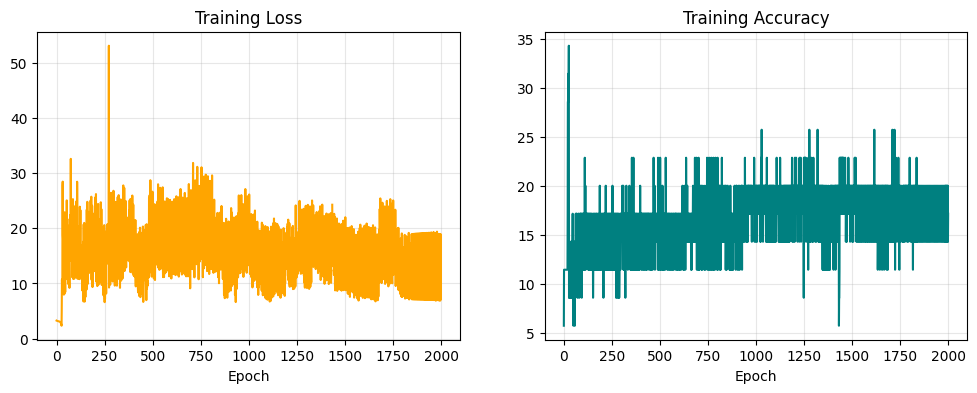


--- SPOT CHECK (Training Data) ---
Input: 'python' 	-> Target: 'is' 	| Pred: 'is' True
Input: 'is' 	-> Target: 'a' 	| Pred: 'a' True
Input: 'a' 	-> Target: 'great' 	| Pred: 'great' True
Input: 'great' 	-> Target: 'programming' 	| Pred: 'the' False
Input: 'programming' 	-> Target: 'language' 	| Pred: 'the' False
Input: 'language' 	-> Target: 'python' 	| Pred: 'the' False
Input: 'python' 	-> Target: 'is' 	| Pred: 'the' False
Input: 'is' 	-> Target: 'used' 	| Pred: 'the' False
Input: 'used' 	-> Target: 'for' 	| Pred: 'the' False
Input: 'for' 	-> Target: 'data' 	| Pred: 'the' False

--- GENERATION TESTS ---
Seed 'python': 	python is a great the the the
Seed 'the': 	the is a great the the the
Seed 'deep': 	deep is a the the the the


In [10]:
# A. Plots: Loss & Accuracy
plt.figure(figsize=(12, 4))

# Plot 1: Loss
plt.subplot(1, 2, 1)
plt.plot(df_history['Epoch'], df_history['Loss'], label='Loss', color='orange')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.grid(True, alpha=0.3)

# Plot 2: Accuracy
plt.subplot(1, 2, 2)
plt.plot(df_history['Epoch'], df_history['Accuracy'], label='Accuracy', color='teal')
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.grid(True, alpha=0.3)

plt.show()

# B. Output Check (Training Data)
print("\n--- SPOT CHECK (Training Data) ---")
# Run one pass
xs, hs, ps = rnn.forward(inputs, np.zeros((128, 1)))

# Check the first 10 predictions
for i in range(10):
    input_word = processor.ix_to_word[inputs[i]]
    true_target = processor.ix_to_word[targets[i]]
    
    # Get the word with the highest score
    pred_ix = np.argmax(ps[i])
    pred_word = processor.ix_to_word[pred_ix]
    
    # Visual check marker
    status = "True" if true_target == pred_word else "False"
    print(f"Input: '{input_word}' \t-> Target: '{true_target}' \t| Pred: '{pred_word}' {status}")

# C. Generation Tests (Context Check)
print("\n--- GENERATION TESTS ---")
seeds = ['python', 'the', 'deep']

for seed in seeds:
    if seed in processor.word_to_ix:
        seed_ix = processor.word_to_ix[seed]
        txt = rnn.predict(seed_ix, processor.ix_to_word, length=6, temperature=1.0)
        print(f"Seed '{seed}': \t{txt}")